In [1]:
import Random: seed!
using MRMP

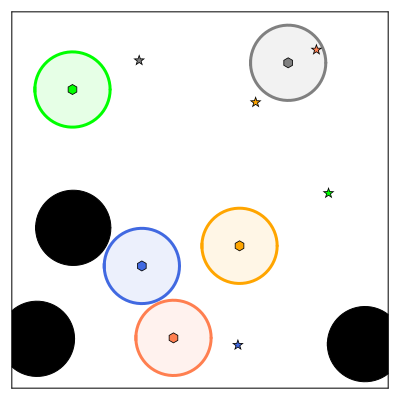

In [2]:
seed!(46)
ins = MRMP.gen_random_instance_StatePoint2D(;
    N = 5,
    rad = 0.1,
    num_obs = 3,
    rad_obs = 0.1,
)
config_init, config_goal, obstacles, ins_params... = ins         # example of ins_params: radius, base positions of arms
MRMP.plot_instance!(ins...)

In [3]:
connect = gen_connect(config_init[1], obstacles, ins_params...)  # connection checker
collide = gen_collide(config_init[1], ins_params...)             # collision checker
check_goal = gen_check_goal(config_goal)                         # goal judge
nothing

In [4]:
@time solution, roadmaps = MRMP.Solvers.SSSP(
    config_init,
    config_goal,
    connect,
    collide,
    check_goal;
    TIME_LIMIT = 10,
)
validate(config_init, connect, collide, check_goal, solution)    # check validity of solution

  0.800832 seconds (4.22 M allocations: 222.751 MiB, 3.43% gc time, 99.16% compilation time)


true

In [5]:
(TPG, solution, cost) = smoothing(solution, connect, collide; VERBOSE=1)
cost

[ Info: cost is updated: 18.051763543416502 -> 8.817601224402935


Dict{Symbol, Float64} with 2 entries:
  :sum_of_cost => 8.8176
  :makespan    => 2.72721

Plots.AnimatedGif("/Users/kei18/Dropbox/work/project/sssp/code/notebooks/tmp.gif")
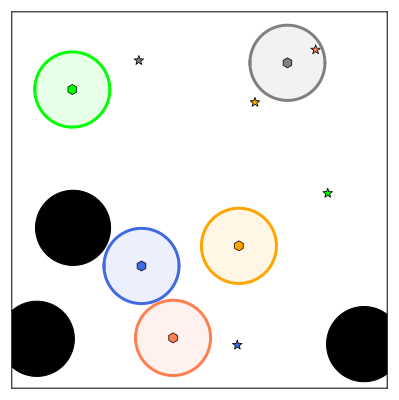

In [8]:
plot_anim!(config_init, config_goal, obstacles, ins_params...; solution=solution, interpolate_depth=3, fps=30)